# HWW Unfolding — Exploratory Plots

General-purpose notebook for inspecting the HWW dataset and unfolding inputs.
Not part of the main analysis pipeline — used for sanity checks and visual insight.

## Contents
-

In [38]:
import os
import sys
sys.path.append("/user/rvanrhee/projects_rik/HWW-unfolding-analysis")

import time
import awkward as ak
import helpers.read_data as rd
import helpers.plotting_features as plotting
from typing import Optional

## Plot number of jets per event for Gen and Reco

In [39]:
Path_Raw = "/data/atlas/users/rvanrhee/hww_parquet/raw/"
Path_Pre = "/data/atlas/users/rvanrhee/hww_parquet/preselection/"

gen_files_raw = sorted([f for f in os.listdir(Path_Raw + "gen/") if f.endswith(".parquet")])
reco_files_raw = sorted([f for f in os.listdir(Path_Raw + "reco/") if f.endswith(".parquet")])

gen_files_pre = sorted([f for f in os.listdir(Path_Pre + "gen/") if f.endswith(".parquet")])
reco_files_pre = sorted([f for f in os.listdir(Path_Pre + "reco/") if f.endswith(".parquet")])

In [40]:
t0 = time.time()

gen_events_raw: Optional[rd.EventObjects] = None
gen_events_pre: Optional[rd.EventObjects] = None

for file in gen_files_raw:
    loaded = rd.load_events(path=Path_Raw + "gen/" + file)
    if gen_events_raw is None:
        gen_events_raw = loaded
    else:
        gen_events_raw += loaded

for file in gen_files_pre:
    loaded = rd.load_events(path=Path_Pre + "gen/" + file)
    if gen_events_pre is None:
        gen_events_pre = loaded
    else:
        gen_events_pre += loaded


t1 = time.time()

print(f"Gens loaded in {t1 - t0:.2f}s")

Gens loaded in 6.36s


In [41]:
t0 = time.time()

reco_events_raw: Optional[rd.EventObjects] = None
reco_events_pre: Optional[rd.EventObjects] = None

for file in reco_files_raw:
    loaded = rd.load_events(path=Path_Raw + "reco/" + file)
    if reco_events_raw is None:
        reco_events_raw = loaded
    else:
        reco_events_raw += loaded

for file in reco_files_pre:
    loaded = rd.load_events(path=Path_Pre + "reco/" + file)
    if reco_events_pre is None:
        reco_events_pre = loaded
    else:
        reco_events_pre += loaded


t1 = time.time()

print(f"Recos loaded in {t1 - t0:.2f}s")

Recos loaded in 3.01s


In [42]:
n_jets_gen_raw = ak.num(gen_events_raw.jets, axis=1)
n_jets_gen_pre = ak.num(gen_events_pre.jets, axis=1)
n_jets_reco_raw = ak.num(reco_events_raw.jets, axis=1)
n_jets_reco_pre = ak.num(reco_events_pre.jets, axis=1)

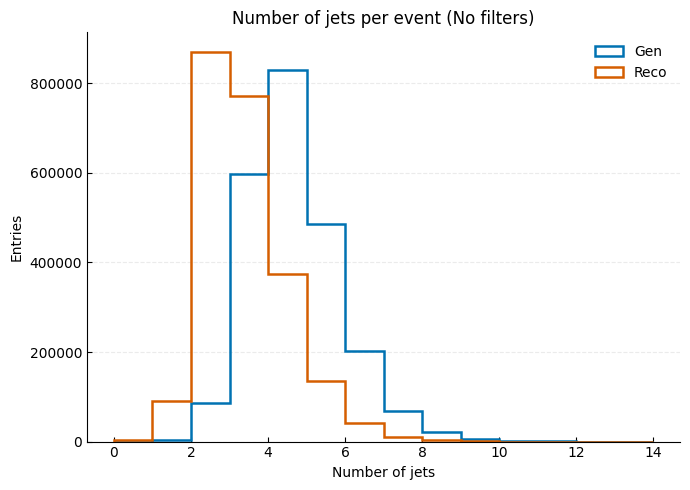

In [46]:
fig, ax = plotting.plot_comparison_hist(
    data=[n_jets_gen_raw, n_jets_reco_raw],
    datanames=["Gen", "Reco"],
    title="Number of jets per event (No filters)",
    xlabel="Number of jets",
    bins=ak.max(ak.concatenate([n_jets_reco_raw, n_jets_gen_raw])),
)

In [ ]:
fig, ax = plotting.plot_comparison_hist(
    data=[n_jets_gen_pre, n_jets_reco_pre],
    datanames=["Gen", "Reco"],
    title="Number of jets per event (After Preselection)",
    xlabel="Number of jets",
    bins=ak.max(ak.concatenate([n_jets_reco_pre, n_jets_gen_pre])),
)